# Pertemuan 7: Clustering (K-Means & Hierarchical)

Nama : ILMA AQSARI  
NIM  : 105841108023  

## Tujuan Praktikum
Pada pertemuan ini saya mempelajari metode Clustering yang termasuk dalam Unsupervised Learning.  
Clustering digunakan untuk mengelompokkan data berdasarkan kemiripan tanpa mengetahui label sebelumnya.

Algoritma yang digunakan:
1. K-Means
2. Hierarchical Clustering
3. Menentukan K Optimal dengan Silhouette Score
4. Studi Kasus Segmentasi Pelanggan

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

## 1. Membuat Dataset Sintetis

In [2]:
X,_ = make_blobs(
    n_samples=300,
    centers=4,
    random_state=42
)

print("Jumlah Data:",X.shape[0])
print("Jumlah Fitur:",X.shape[1])

Jumlah Data: 300
Jumlah Fitur: 2


## 2. KMeans Clustering

In [3]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

labels_k = kmeans.fit_predict(X)

print("Inertia:",round(kmeans.inertia_,2))
print("Silhouette Score:",round(silhouette_score(X,labels_k),3))

Inertia: 564.91
Silhouette Score: 0.792


## 3. Hierarchical Clustering

In [4]:
agg = AgglomerativeClustering(n_clusters=4)
labels_h = agg.fit_predict(X)

print("Silhouette Score:",round(silhouette_score(X,labels_h),3))

Silhouette Score: 0.792


## 4. Menentukan K Optimal

In [5]:
inertia=[]
silhouette=[]

K_range=range(2,11)

for k in K_range:

    model=KMeans(n_clusters=k, random_state=42)
    label=model.fit_predict(X)

    inertia.append(model.inertia_)
    sil=silhouette_score(X,label)
    silhouette.append(sil)

    print("K =",k,
          "Inertia =",round(model.inertia_,1),
          "Silhouette =",round(sil,3))

best_k=list(K_range)[np.argmax(silhouette)]
print("\nK Optimal =",best_k)

K = 2 Inertia = 9416.2 Silhouette = 0.59
K = 3 Inertia = 2110.4 Silhouette = 0.757
K = 4 Inertia = 564.9 Silhouette = 0.792
K = 5 Inertia = 513.0 Silhouette = 0.664
K = 6 Inertia = 462.1 Silhouette = 0.533
K = 7 Inertia = 411.3 Silhouette = 0.426
K = 8 Inertia = 365.4 Silhouette = 0.335
K = 9 Inertia = 332.0 Silhouette = 0.345
K = 10 Inertia = 291.6 Silhouette = 0.362

K Optimal = 4


## 5. Grafik Elbow dan Silhouette

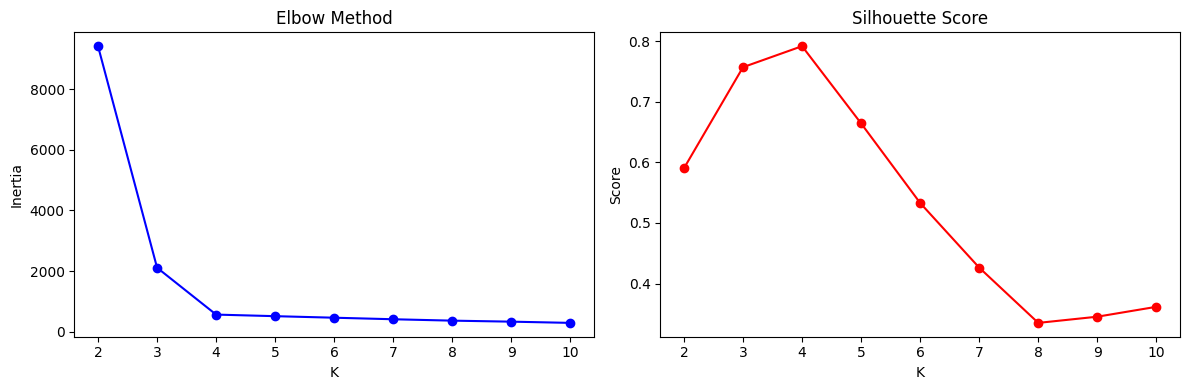

In [6]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(list(K_range),inertia,"bo-")
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(list(K_range),silhouette,"ro-")
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

## 6. Studi Kasus Segmentasi Pelanggan

In [7]:
np.random.seed(42)

income=np.concatenate([
np.random.normal(30,5,50),
np.random.normal(30,5,50),
np.random.normal(70,8,50),
np.random.normal(70,8,50)
])

spending=np.concatenate([
np.random.normal(20,5,50),
np.random.normal(70,5,50),
np.random.normal(20,5,50),
np.random.normal(70,5,50)
])

X_cust=np.column_stack([income,spending])

model=KMeans(n_clusters=4,random_state=42)
label=model.fit_predict(X_cust)

print("Profil Cluster")

for c in sorted(set(label)):
    mask=label==c
    print("\nCluster",c)
    print("Rata Income:",round(income[mask].mean(),1))
    print("Rata Spending:",round(spending[mask].mean(),1))
    print("Jumlah:",mask.sum())

Profil Cluster

Cluster 0
Rata Income: 30.1
Rata Spending: 69.9
Jumlah: 50

Cluster 1
Rata Income: 70.7
Rata Spending: 70.9
Jumlah: 50

Cluster 2
Rata Income: 28.9
Rata Spending: 20.8
Jumlah: 50

Cluster 3
Rata Income: 69.7
Rata Spending: 20.2
Jumlah: 50


## 7. Visualisasi Segmentasi

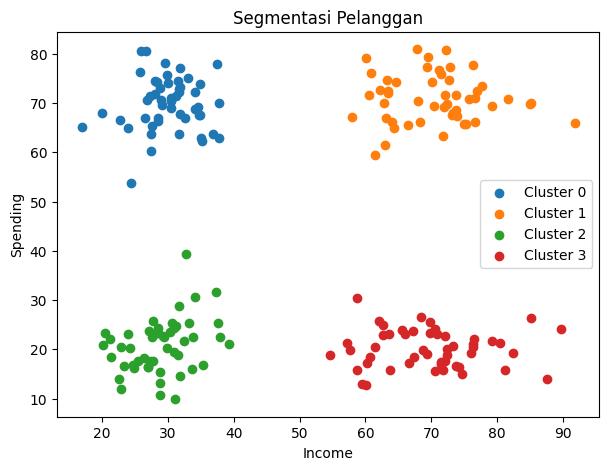

In [8]:
plt.figure(figsize=(7,5))

for c in sorted(set(label)):
    mask=label==c
    plt.scatter(income[mask],spending[mask],label="Cluster "+str(c))

plt.xlabel("Income")
plt.ylabel("Spending")
plt.legend()
plt.title("Segmentasi Pelanggan")
plt.show()

## 8. Kesimpulan

In [9]:
print("1. KMeans dapat mengelompokkan pelanggan menjadi beberapa segmen.")
print("2. Nilai K optimal dapat ditentukan menggunakan metode Silhouette.")
print("3. Clustering dapat membantu strategi pemasaran.")

1. KMeans dapat mengelompokkan pelanggan menjadi beberapa segmen.
2. Nilai K optimal dapat ditentukan menggunakan metode Silhouette.
3. Clustering dapat membantu strategi pemasaran.


In [10]:
print("\n✅ Pertemuan 7 Selesai")


✅ Pertemuan 7 Selesai
